# Part F: Support Vector Regression (SVR)

Linear SVR, RBF SVR, Hyperparameter Tuning and Evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('Advanced Regression HousePrice.csv')
df.head()


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [10]:
if 'sale_date' in df.columns:
    df['sale_date'] = pd.to_datetime(df['sale_date'])
    df['sale_year'] = df['sale_date'].dt.year
    df['sale_month'] = df['sale_date'].dt.month
    df.drop('sale_date', axis=1, inplace=True)

X = df.drop(columns=['house_price_inr'])
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='linear'))
])

linear_cv = GridSearchCV(
    linear_pipe,
    {'svr__C':[0.1,1,10], 'svr__epsilon':[0.01,0.1,1]},
    cv=5,
    scoring='r2'
)

linear_cv.fit(X_train, y_train)
best_linear = linear_cv.best_estimator_
print(linear_cv.best_params_)


{'svr__C': 10, 'svr__epsilon': 0.01}


In [4]:
rbf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

rbf_cv = GridSearchCV(
    rbf_pipe,
    {'svr__C':[1,10,100],
     'svr__gamma':['scale','auto',0.01],
     'svr__epsilon':[0.01,0.1,1]},
    cv=5,
    scoring='r2'
)

rbf_cv.fit(X_train, y_train)
best_rbf = rbf_cv.best_estimator_
print(rbf_cv.best_params_)


{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}


In [7]:
linear_pred = best_linear.predict(X_test)
rbf_pred = best_rbf.predict(X_test)

results = pd.DataFrame({
    'Model':['Linear SVR','RBF SVR'],
    'RMSE':[
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rbf_pred))
    ],
    'MAE':[
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rbf_pred)
    ],
    'R2':[
        r2_score(y_test, linear_pred),
        r2_score(y_test, rbf_pred)
    ]
})

results


,Model,RMSE,MAE,R2
0,Linear SVR,8.939707e+06,6.956484e+06,0.007659
1,RBF SVR,8.977865e+06,6.986199e+06,-0.000831


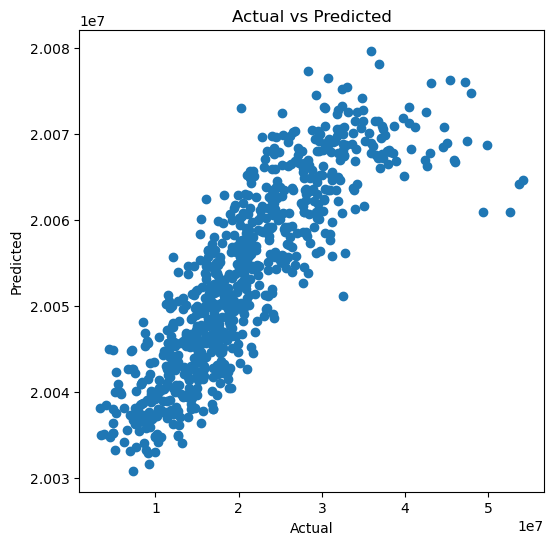

In [8]:
best_pred = rbf_pred

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()
